# Avance 4 — Modelos alternativos (REINSURE.AI)



Equipo: Avance4_#Equipo1


Integrantes:

- Alejandra Berenice Vega López - a01795415@tec.mx

- Paul Andrés Yungán Pinduisaca - a01795702@tec.mx

- Jonathan Ardash Hernández Cruz - a01795404@tec.mx


En esta etapa del proyecto REINSURE.AI implica probar diferentes modelos de lenguaje (LLM) y configuraciones relevantes para resolver el problema de comparación de texto y evaluar su desempeño. En este caso, se experimentará con distintos modelos de OpenAI, como GPT-4o-mini, GPT-4o y GPT-3.5-turbo, con el fin de analizar sus diferencias en precisión, coherencia semántica y costo computacional.

Distintos modelos o variantes pueden comportarse de manera más eficiente dependiendo del tipo de texto, el contexto semántico o la tarea específica (por ejemplo, detección de similitud, resumen o análisis de coincidencias).

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


## Carga y exploración de datos

En este paso se cargó el dataset `reinsurance_data_thb_10.csv`, compuesto por registros  que representan tanto pre-notas de cobertura como soportes.  

El propósito de esta fase es validar la estructura de los datos, revisar tipos de variables y preparar el conjunto para su división entre documentos comparables.

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Proyecto_Integrador/"

# Se carga el dataset
df = pd.read_csv(DATA_PATH + "reinsurance_data_thb_10.csv")
display(df.head())
display(df.info())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Folio,record_type,tipo,ramo,reinsurer,participation,reasegurado,asegurado,direccion,periodo_inicio,...,prima_neta,soporte,base_cobertura,territorialidad,jurisdiccion,dias_pago,anexos_clausulas,texto_clausulas,panel_participantes,moneda
0,NC/000001/2016/2017,Pre-nota de Cobertura,Reaseguro Facultativo,Transportes,"Mercury, Pisces",100,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,4003402,100,Claims Made,México,Leyes mexicanas,26,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
1,NC/000001/2016/2017,Soporte,Reaseguro Facultativo,Transportes,Mercury,55,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,2201871,55,Claims Made,México,Leyes mexicanas,36,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
2,NC/000001/2016/2017,Soporte,Reaseguro Facultativo,Transportes,Pisces,45,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,1801531,45,Claims Made,México,Leyes mexicanas,54,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
3,NC/000002/2024/2025,Pre-nota de Cobertura,Reaseguro Facultativo,Responsabilidad Civil,Andromeda,100,Aseguradora del Norte,"Tecnologías Avanzadas, S.A.","Tijuana, Baja California",23/04/24 0:00,...,4955124,100,Claims Made,México,Leyes mexicanas,30,"NMA 2737, LMA 3100A, Endorsement 1234, NMA 280...","Cooperacion de reclamos, Limitación de Sancion...",Andromeda 100%,MXN
4,NC/000002/2024/2025,Soporte,Reaseguro Facultativo,Responsabilidad Civil,Andromeda,100,Aseguradora del Norte,"Tecnologías Avanzadas, S.A.","Tijuana, Baja California",23/04/24 0:00,...,4955124,100,Claims Made,México,Leyes mexicanas,54,"NMA 2737, LMA 3100A, Endorsement 1234, NMA 280...","Cooperacion de reclamos, Limitación de Sancion...",Andromeda 100%,MXN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 33 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Folio                  42 non-null     object
 1   record_type            42 non-null     object
 2   tipo                   42 non-null     object
 3   ramo                   42 non-null     object
 4   reinsurer              42 non-null     object
 5   participation          42 non-null     int64 
 6   reasegurado            42 non-null     object
 7   asegurado              42 non-null     object
 8   direccion              42 non-null     object
 9   periodo_inicio         42 non-null     object
 10  periodo_fin            42 non-null     object
 11  actividad              42 non-null     object
 12  estimado_ingresos      42 non-null     int64 
 13  interes_asegurable     42 non-null     object
 14  limite_max_res         42 non-null     int64 
 15  riesgos_cubiertos      42

None

## Dividir los datos


Crear dos nuevos dataframes, uno para los registros de tipo 'prenota de cobertura' y otro para los registros de tipo 'soporte', basándose en la columna relevante (que habrá que identificar en los datos).


In [ ]:
df_prenota = df[df['record_type'] == 'Pre-nota de Cobertura']
df_soporte = df[df['record_type'] == 'Soporte']

display(df_prenota.head())
display(df_soporte.head())

,Folio,record_type,tipo,ramo,reinsurer,participation,reasegurado,asegurado,direccion,periodo_inicio,...,prima_neta,soporte,base_cobertura,territorialidad,jurisdiccion,dias_pago,anexos_clausulas,texto_clausulas,panel_participantes,moneda
0,NC/000001/2016/2017,Pre-nota de Cobertura,Reaseguro Facultativo,Transportes,"Mercury, Pisces",100,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,4003402,100,Claims Made,México,Leyes mexicanas,26,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
3,NC/000002/2024/2025,Pre-nota de Cobertura,Reaseguro Facultativo,Responsabilidad Civil,Andromeda,100,Aseguradora del Norte,"Tecnologías Avanzadas, S.A.","Tijuana, Baja California",23/04/24 0:00,...,4955124,100,Claims Made,México,Leyes mexicanas,30,"NMA 2737, LMA 3100A, Endorsement 1234, NMA 280...","Cooperacion de reclamos, Limitación de Sancion...",Andromeda 100%,MXN
5,NC/000003/2018/2019,Pre-nota de Cobertura,Reaseguro Facultativo,Ramos Técnicos,"Saturn, UrsaMajor, Andromeda",100,Aseguradora del Norte,"Transporte Global, S.A.",Ciudad de México,26/01/18 0:00,...,3639704,100,Claims Made,México,Leyes mexicanas,57,"NMA 2737, NMA 2705, NMA 464, Endorsement 9101,...","Cooperacion de reclamos, Acción Razonable; Exc...","Saturn 14%, UrsaMajor 49%, Andromeda 37%",MXN
9,NC/000004/2017/2018,Pre-nota de Cobertura,Reaseguro Facultativo,Transportes,Jupiter,100,"Seguros Central, S.A.","Servicios Integrales del Valle, S.A. de C.V.","Monterrey, Nuevo León",14/11/17 0:00,...,7952574,100,Claims Made,México,Leyes mexicanas,31,"NMA 2737, NMA 2738, Endorsement 5678, NMA 3001...","Cooperacion de reclamos, Control de Pérdidas; ...",Jupiter 100%,MXN
11,NC/000005/2024/2025,Pre-nota de Cobertura,Reaseguro Facultativo,Responsabilidad Ambiental,"Orion, Taurus, Pegasus, Scorpius, Uranus, Jupi...",100,Grupo Financiero Unión,"Transporte Global, S.A.","San Luis Potosí, San Luis Potosí",07/07/24 0:00,...,3474754,100,Claims Made,México,Leyes mexicanas,34,"NMA 2737, NMA 2738, Endorsement 1234, LMA 3092...","Cooperacion de reclamos, Control de Pérdidas; ...","Orion 2%, Taurus 5%, Pegasus 14%, Scorpius 11%...",USD


,Folio,record_type,tipo,ramo,reinsurer,participation,reasegurado,asegurado,direccion,periodo_inicio,...,prima_neta,soporte,base_cobertura,territorialidad,jurisdiccion,dias_pago,anexos_clausulas,texto_clausulas,panel_participantes,moneda
1,NC/000001/2016/2017,Soporte,Reaseguro Facultativo,Transportes,Mercury,55,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,2201871,55,Claims Made,México,Leyes mexicanas,36,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
2,NC/000001/2016/2017,Soporte,Reaseguro Facultativo,Transportes,Pisces,45,Aseguradora del Norte,Servicios Financieros Unión,"San Luis Potosí, San Luis Potosí",14/10/16 0:00,...,1801531,45,Claims Made,México,Leyes mexicanas,54,"NMA 2737, Endorsement 5678, NMA 2962, LMA 3092...","Cooperacion de reclamos, All Risks; Prevención...","Mercury 55%, Pisces 45%",MXN
4,NC/000002/2024/2025,Soporte,Reaseguro Facultativo,Responsabilidad Civil,Andromeda,100,Aseguradora del Norte,"Tecnologías Avanzadas, S.A.","Tijuana, Baja California",23/04/24 0:00,...,4955124,100,Claims Made,México,Leyes mexicanas,54,"NMA 2737, LMA 3100A, Endorsement 1234, NMA 280...","Cooperacion de reclamos, Limitación de Sancion...",Andromeda 100%,MXN
6,NC/000003/2018/2019,Soporte,Reaseguro Facultativo,Ramos Técnicos,Saturn,14,Aseguradora del Norte,"Transporte Global, S.A.",Ciudad de México,26/01/18 0:00,...,509559,14,Claims Made,México,Leyes mexicanas,47,"NMA 2737, NMA 2705, NMA 464, Endorsement 9101,...","Cooperacion de reclamos, Acción Razonable; Exc...","Saturn 14%, UrsaMajor 49%, Andromeda 37%",MXN
7,NC/000003/2018/2019,Soporte,Reaseguro Facultativo,Ramos Técnicos,UrsaMajor,49,Aseguradora del Norte,"Transporte Global, S.A.",Ciudad de México,26/01/18 0:00,...,1783455,49,Claims Made,México,Leyes mexicanas,57,"NMA 2737, NMA 2705, NMA 464, Endorsement 9101,...","Cooperacion de reclamos, Acción Razonable; Exc...","Saturn 14%, UrsaMajor 49%, Andromeda 37%",MXN


## Preparar los datos para la comparación

Seleccionar las variables relevantes de cada dataframe para la comparación y, si es necesario, preprocesar los datos (por ejemplo, manejar valores nulos, formatear cadenas, etc.).


In [ ]:
import numpy as np
import pandas as pd

# Crea df_prenota y df_soporte
df_prenota = df[df['record_type'] == 'Pre-nota de Cobertura']
df_soporte = df[df['record_type'] == 'Soporte']

# Identifica las columnas relevantes
# Se obtienen todas las columnas después de 'record_type'
all_columns = df.columns.tolist()
start_index = all_columns.index('ramo')
relevant_columns = all_columns[start_index:]

# Se excluyen las columnas que claramente no son basadas en texto o adecuadas para comparación de texto
excluded_columns = ['participation', 'estimado_ingresos', 'limite_max_res',
                    'deducible_General', 'deducible_Robo', 'deducible_Terremoto',
                    'deducible_Electricos', 'deducible_Ingresos', 'soporte', 'dias_pago']

relevant_columns = [col for col in relevant_columns if col not in excluded_columns]

print(f"Columnas relevantes para la comparación: {relevant_columns}")


# Se manejan los valores faltantes y asegura el tipo de cadena
# Usa .copy() para evitar SettingWithCopyWarning
df_prenota = df_prenota.copy()
df_soporte = df_soporte.copy()

for col in relevant_columns:
    df_prenota[col] = df_prenota[col].fillna('').astype(str)
    df_soporte[col] = df_soporte[col].fillna('').astype(str)

# Se limpian texto (minúsculas y eliminación de puntuación)
# Usa doble barra invertida para secuencias de escape regex para evitar SyntaxWarning
df_prenota[relevant_columns] = df_prenota[relevant_columns].apply(lambda x: x.str.lower().str.replace('[^\\w\\s]', '', regex=True))
df_soporte[relevant_columns] = df_soporte[relevant_columns].apply(lambda x: x.str.lower().str.replace('[^\\w\\s]', '', regex=True))

# Se crea un dataframe combinado con texto de soporte concatenado para cada Folio
agg_dict = {col: lambda x: ' '.join(x) for col in relevant_columns}
df_soporte_agg = df_soporte.groupby('Folio')[relevant_columns].agg(agg_dict).reset_index()

# Se fusiona por Folio e incluye todas las columnas relevantes de prenota también
df_combined = pd.merge(df_prenota[['Folio'] + relevant_columns], df_soporte_agg, on='Folio', suffixes=('_prenota', '_soporte'))


display(df_combined.head())

Columnas relevantes para la comparación: ['ramo', 'reinsurer', 'reasegurado', 'asegurado', 'direccion', 'periodo_inicio', 'periodo_fin', 'actividad', 'estimado_ingresos ', 'interes_asegurable', 'limite_max_res ', 'riesgos_cubiertos', 'condiciones_reaseguro', 'exclusiones', 'deducible_General ', 'deducible_Robo ', 'deducible_Terremoto ', 'deducible_Electricos ', 'deducible_Ingresos ', 'prima_neta ', 'base_cobertura', 'territorialidad', 'jurisdiccion', 'anexos_clausulas', 'texto_clausulas', 'panel_participantes', 'moneda']


,Folio,ramo_prenota,reinsurer_prenota,reasegurado_prenota,asegurado_prenota,direccion_prenota,periodo_inicio_prenota,periodo_fin_prenota,actividad_prenota,estimado_ingresos _prenota,...,deducible_Electricos _soporte,deducible_Ingresos _soporte,prima_neta _soporte,base_cobertura_soporte,territorialidad_soporte,jurisdiccion_soporte,anexos_clausulas_soporte,texto_clausulas_soporte,panel_participantes_soporte,moneda_soporte
0,NC/000001/2016/2017,transportes,mercury pisces,aseguradora del norte,servicios financieros unión,san luis potosí san luis potosí,141016 000,141017 000,operación de transporte terrestre,13575562,...,93563 93563,46062 46062,2201871 1801531,claims made claims made,méxico méxico,leyes mexicanas leyes mexicanas,nma 2737 endorsement 5678 nma 2962 lma 3092 lm...,cooperacion de reclamos all risks prevención d...,mercury 55 pisces 45 mercury 55 pisces 45,mxn mxn
1,NC/000002/2024/2025,responsabilidad civil,andromeda,aseguradora del norte,tecnologías avanzadas sa,tijuana baja california,230424 000,230425 000,prestación de servicios,89753260,...,69823,56434,4955124,claims made,méxico,leyes mexicanas,nma 2737 lma 3100a endorsement 1234 nma 2800 n...,cooperacion de reclamos limitación de sancione...,andromeda 100,mxn
2,NC/000003/2018/2019,ramos técnicos,saturn ursamajor andromeda,aseguradora del norte,transporte global sa,ciudad de méxico,260118 000,260119 000,ingeniería y construcción,36935572,...,85435 85435 85435,71856 71856 71856,509559 1783455 1346690,claims made claims made claims made,méxico méxico méxico,leyes mexicanas leyes mexicanas leyes mexicanas,nma 2737 nma 2705 nma 464 endorsement 9101 nma...,cooperacion de reclamos acción razonable exclu...,saturn 14 ursamajor 49 andromeda 37 saturn 14 ...,mxn mxn mxn
3,NC/000004/2017/2018,transportes,jupiter,seguros central sa,servicios integrales del valle sa de cv,monterrey nuevo león,141117 000,141118 000,operación de transporte terrestre,52642594,...,21504,35014,7952574,claims made,méxico,leyes mexicanas,nma 2737 nma 2738 endorsement 5678 nma 3001 lm...,cooperacion de reclamos control de pérdidas al...,jupiter 100,mxn
4,NC/000005/2024/2025,responsabilidad ambiental,orion taurus pegasus scorpius uranus jupiter d...,grupo financiero unión,transporte global sa,san luis potosí san luis potosí,070724 000,070725 000,gestión medioambiental,98969689,...,77422 77422 77422 77422 77422 77422 77422 7742...,87839 87839 87839 87839 87839 87839 87839 8783...,69495 173738 486466 382223 104243 104243 27798...,claims made claims made claims made claims mad...,méxico méxico méxico méxico méxico méxico méxi...,leyes mexicanas leyes mexicanas leyes mexicana...,nma 2737 nma 2738 endorsement 1234 lma 3092 lm...,cooperacion de reclamos control de pérdidas ex...,orion 2 taurus 5 pegasus 14 scorpius 11 uranus...,usd usd usd usd usd usd usd usd usd usd usd us...


## Configurar la api de openai

Configurar la clave de API de OpenAI para poder realizar llamadas a la API.


In [ ]:
import openai
import os

openai.api_key = 'sk-proj-fake'


## Comparar variables usando la api de openai

Utilizando la API de OpenAI y el modelo `gpt-4o`, `gpt-4o-mini` y `gpt-3.5-turbo`, se implementó la función `get_similarity_score()`, que retorna una puntuación entre **0 y 1**, donde:
- 1 representa una coincidencia semántica completa.
- 0 indica ausencia total de similitud.

Se aplicó un enfoque con lógica de reintento y control de errores para evitar interrupciones por límites de tasa.  


In [ ]:
from tenacity import retry, wait_random_exponential, stop_after_attempt
import time
import numpy as np
import re # Se importa el módulo re para expresiones regulares

# Se define la función de cálculo de similitud con lógica de reintento
@retry(wait=wait_random_exponential(min=1, max=60), stop=stop_after_attempt(6))
def get_similarity_score(text1, text2):
    """Calcula una puntuación de similitud entre dos entradas de texto usando la API de OpenAI."""
    try:
        response = openai.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": "Eres un asistente útil que compara dos textos y proporciona una puntuación de similitud entre 0 y 1, donde 1 es muy similar y 0 no es similar. Proporciona SOLO la puntuación numérica."},
                {"role": "user", "content": f"Compara los siguientes dos textos y proporciona una puntuación de similitud:\n\nTexto 1: {text1}\n\nTexto 2: {text2}\n\nPuntuación de Similitud:"}
            ],
            max_completion_tokens=10
            #max_tokens=10,
            #temperature=0
        )
        score_str = response.choices[0].message.content.strip()
        try:
            # Intenta convertir la puntuación a un número flotante
            score = float(score_str)
            # Nos aseguramos de que la puntuación esté dentro del rango 0-1
            score = max(0, min(1, score))
            #print(f"Puntuación obtenida con éxito: {score}") # Se añadió print para éxito
            return score
        except ValueError:
            # Se usa regex para encontrar una puntuación numérica en la respuesta si la conversión directa falla
            match = re.search(r'\d+\.?\d*', score_str)
            if match:
                score = float(match.group(0))
                score = max(0, min(1, score))
                print(f"Advertencia: Puntuación '{score}' extraída de respuesta no numérica de la API: {score_str}")
                return score
            else:
                print(f"Advertencia: No se pudo convertir o extraer la puntuación de la respuesta de la API: {score_str}")
                return np.nan # Devuelve NaN en caso de que no se encuentre una puntuación válida
    except Exception as e:
        print(f"Error durante la llamada a la API de OpenAI: {e}")
        return np.nan # Devuelve NaN en caso de errores de la API

# Se identifican las columnas relevantes (definidas en el paso anterior pero necesarias aquí)
relevant_columns = ['ramo', 'reinsurer', 'reasegurado', 'asegurado', 'direccion', 'periodo_inicio', 'periodo_fin', 'actividad', 'estimado_ingresos ', 'interes_asegurable', 'limite_max_res ', 'riesgos_cubiertos', 'condiciones_reaseguro', 'exclusiones', 'deducible_General ', 'deducible_Robo ', 'deducible_Terremoto ', 'deducible_Electricos ', 'deducible_Ingresos ', 'prima_neta ', 'base_cobertura', 'territorialidad', 'jurisdiccion', 'anexos_clausulas', 'texto_clausulas', 'panel_participantes', 'moneda']


# Se limita a las primeras 5 filas para probar
#df_combined_subset = df_combined.head(5).copy()
# Se calcula los indices de similitud para el dataset completo (Implica un mayor costo por el uso del API de OpenAI)
df_combined_subset = df_combined.copy()

# Start timing
start_time = time.time()

# Se itera y calcula las puntuaciones de similitud
for col in relevant_columns:
    prenota_col = f'{col}_prenota'
    soporte_col = f'{col}_soporte'
    similarity_col = f'similarity_{col}'
    df_combined_subset[similarity_col] = np.nan # Inicializa con NaN

    for index, row in df_combined_subset.iterrows():
        text_prenota = row[prenota_col]
        text_soporte = row[soporte_col]

        #print(f"Procesando Folio: {row['Folio']}, Columna: {col}") # Se añadió print para mostrar el progreso

        # Se calcula la similitud solo si ambos textos no están vacíos
        if text_prenota and text_soporte:
            similarity_score = get_similarity_score(text_prenota, text_soporte)
            df_combined_subset.at[index, similarity_col] = similarity_score
        else:
            df_combined_subset.at[index, similarity_col] = 0 # Asigna 0 de similitud si uno o ambos textos están vacíos
            print(f"Saltando cálculo de similitud debido a texto vacío para Folio: {row['Folio']}, Columna: {col}") # Se añadió print para saltar

        # Añade un pequeño retraso para evitar alcanzar los límites de tasa
        time.sleep(0.1)

# End timing
end_time = time.time()
execution_time_gpt4o = end_time - start_time


display(df_combined_subset.head())

,Folio,ramo_prenota,reinsurer_prenota,reasegurado_prenota,asegurado_prenota,direccion_prenota,periodo_inicio_prenota,periodo_fin_prenota,actividad_prenota,estimado_ingresos _prenota,...,similarity_deducible_Electricos,similarity_deducible_Ingresos,similarity_prima_neta,similarity_base_cobertura,similarity_territorialidad,similarity_jurisdiccion,similarity_anexos_clausulas,similarity_texto_clausulas,similarity_panel_participantes,similarity_moneda
0,NC/000001/2016/2017,transportes,mercury pisces,aseguradora del norte,servicios financieros unión,san luis potosí san luis potosí,141016 000,141017 000,operación de transporte terrestre,13575562,...,0.50,0.8,0.0,0.80,0.8,0.8,0.85,0.85,0.75,0.5
1,NC/000002/2024/2025,responsabilidad civil,andromeda,aseguradora del norte,tecnologías avanzadas sa,tijuana baja california,230424 000,230425 000,prestación de servicios,89753260,...,1.00,1.0,1.0,1.00,1.0,1.0,1.00,1.00,1.00,1.0
2,NC/000003/2018/2019,ramos técnicos,saturn ursamajor andromeda,aseguradora del norte,transporte global sa,ciudad de méxico,260118 000,260119 000,ingeniería y construcción,36935572,...,0.67,0.8,0.0,0.67,0.8,1.0,0.80,0.90,0.75,0.5
3,NC/000004/2017/2018,transportes,jupiter,seguros central sa,servicios integrales del valle sa de cv,monterrey nuevo león,141117 000,141118 000,operación de transporte terrestre,52642594,...,1.00,1.0,1.0,1.00,1.0,1.0,1.00,1.00,1.00,1.0
4,NC/000005/2024/2025,responsabilidad ambiental,orion taurus pegasus scorpius uranus jupiter d...,grupo financiero unión,transporte global sa,san luis potosí san luis potosí,070724 000,070725 000,gestión medioambiental,98969689,...,0.50,0.3,0.0,0.75,1.0,1.0,1.00,0.50,0.25,0.7


In [ ]:
# Se calcula y Muestran estadisticas
import time

# Seleccionar solo las columnas con similaridad
similarity_columns = [col for col in df_combined_subset.columns if col.startswith("similarity_")]

# Calcular el numero total de celdas y numero de diferencias
total_cells = df_combined_subset[similarity_columns].size
differences_count = (df_combined_subset[similarity_columns] != 1).sum().sum()
perfect_matches_count = (df_combined_subset[similarity_columns] == 1).sum().sum()
nan_count = df_combined_subset[similarity_columns].isna().sum().sum()

# Media general de similaridad
overall_mean_similarity = df_combined_subset[similarity_columns].mean().mean()


print("\n--- Similarity Analysis Statistics (gpt-4o) ---")
print(f"Execution Time: {execution_time_gpt4o:.2f} seconds")
print(f"Total number of comparisons: {total_cells}")
print(f"Number of perfect matches (similarity = 1): {perfect_matches_count}")
print(f"Number of differences (similarity != 1): {differences_count}")
print(f"Number of missing scores (NaN): {nan_count}")
print(f"Overall Mean Similarity Score: {overall_mean_similarity:.4f}")
print("------------------------------------")


--- Similarity Analysis Statistics (gpt-4o) ---
Execution Time: 160.83 seconds
Total number of comparisons: 270
Number of perfect matches (similarity = 1): 122
Number of differences (similarity != 1): 148
Number of missing scores (NaN): 0
Overall Mean Similarity Score: 0.7885
------------------------------------


In [ ]:
from tenacity import retry, wait_random_exponential, stop_after_attempt
import time
import numpy as np
import re # Se importa el módulo re para expresiones regulares

# Se define la función de cálculo de similitud con lógica de reintento
@retry(wait=wait_random_exponential(min=1, max=60), stop=stop_after_attempt(6))
def get_similarity_score(text1, text2):
    """Calcula una puntuación de similitud entre dos entradas de texto usando la API de OpenAI."""
    try:
        response = openai.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": "Eres un asistente útil que compara dos textos y proporciona una puntuación de similitud entre 0 y 1, donde 1 es muy similar y 0 no es similar. Proporciona SOLO la puntuación numérica."},
                {"role": "user", "content": f"Compara los siguientes dos textos y proporciona una puntuación de similitud:\n\nTexto 1: {text1}\n\nTexto 2: {text2}\n\nPuntuación de Similitud:"}
            ],
            #max_completion_tokens=10
            max_tokens=10,
            temperature=0
        )
        score_str = response.choices[0].message.content.strip()
        try:
            # Intenta convertir la puntuación a un número flotante
            score = float(score_str)
            # Nos aseguramos de que la puntuación esté dentro del rango 0-1
            score = max(0, min(1, score))
            #print(f"Puntuación obtenida con éxito: {score}") # Se añadió print para éxito
            return score
        except ValueError:
            # Se usa regex para encontrar una puntuación numérica en la respuesta si la conversión directa falla
            match = re.search(r'\d+\.?\d*', score_str)
            if match:
                score = float(match.group(0))
                score = max(0, min(1, score))
                print(f"Advertencia: Puntuación '{score}' extraída de respuesta no numérica de la API: {score_str}")
                return score
            else:
                print(f"Advertencia: No se pudo convertir o extraer la puntuación de la respuesta de la API: {score_str}")
                return np.nan # Devuelve NaN en caso de que no se encuentre una puntuación válida
    except Exception as e:
        print(f"Error durante la llamada a la API de OpenAI: {e}")
        return np.nan # Devuelve NaN en caso de errores de la API

# Se identifican las columnas relevantes (definidas en el paso anterior pero necesarias aquí)
relevant_columns = ['ramo', 'reinsurer', 'reasegurado', 'asegurado', 'direccion', 'periodo_inicio', 'periodo_fin', 'actividad', 'estimado_ingresos ', 'interes_asegurable', 'limite_max_res ', 'riesgos_cubiertos', 'condiciones_reaseguro', 'exclusiones', 'deducible_General ', 'deducible_Robo ', 'deducible_Terremoto ', 'deducible_Electricos ', 'deducible_Ingresos ', 'prima_neta ', 'base_cobertura', 'territorialidad', 'jurisdiccion', 'anexos_clausulas', 'texto_clausulas', 'panel_participantes', 'moneda']


# Se limita a las primeras 5 filas para probar
#df_combined_subset = df_combined.head(5).copy()
# Se calcula los indices de similitud para el dataset completo (Implica un mayor costo por el uso del API de OpenAI)
df_combined_subset = df_combined.copy()

# Start timing for gpt-4o-mini
start_time_gpt4omini = time.time()

# Se itera y calcula las puntuaciones de similitud
for col in relevant_columns:
    prenota_col = f'{col}_prenota'
    soporte_col = f'{col}_soporte'
    similarity_col = f'similarity_{col}'
    df_combined_subset[similarity_col] = np.nan # Inicializa con NaN

    for index, row in df_combined_subset.iterrows():
        text_prenota = row[prenota_col]
        text_soporte = row[soporte_col]

        #print(f"Procesando Folio: {row['Folio']}, Columna: {col}") # Se añadió print para mostrar el progreso

        # Se calcula la similitud solo si ambos textos no están vacíos
        if text_prenota and text_soporte:
            similarity_score = get_similarity_score(text_prenota, text_soporte)
            df_combined_subset.at[index, similarity_col] = similarity_score
        else:
            df_combined_subset.at[index, similarity_col] = 0 # Asigna 0 de similitud si uno o ambos textos están vacíos
            print(f"Saltando cálculo de similitud debido a texto vacío para Folio: {row['Folio']}, Columna: {col}") # Se añadió print para saltar

        # Añade un pequeño retraso para evitar alcanzar los límites de tasa
        time.sleep(0.1)

# End timing for gpt-4o-mini
end_time_gpt4omini = time.time()
execution_time_gpt4omini = end_time_gpt4omini - start_time_gpt4omini

display(df_combined_subset.head())

,Folio,ramo_prenota,reinsurer_prenota,reasegurado_prenota,asegurado_prenota,direccion_prenota,periodo_inicio_prenota,periodo_fin_prenota,actividad_prenota,estimado_ingresos _prenota,...,similarity_deducible_Electricos,similarity_deducible_Ingresos,similarity_prima_neta,similarity_base_cobertura,similarity_territorialidad,similarity_jurisdiccion,similarity_anexos_clausulas,similarity_texto_clausulas,similarity_panel_participantes,similarity_moneda
0,NC/000001/2016/2017,transportes,mercury pisces,aseguradora del norte,servicios financieros unión,san luis potosí san luis potosí,141016 000,141017 000,operación de transporte terrestre,13575562,...,0.8,0.5,0.0,0.75,0.5,0.8,0.75,0.85,0.8,0.5
1,NC/000002/2024/2025,responsabilidad civil,andromeda,aseguradora del norte,tecnologías avanzadas sa,tijuana baja california,230424 000,230425 000,prestación de servicios,89753260,...,1.0,1.0,1.0,1.00,1.0,1.0,1.00,1.00,1.0,1.0
2,NC/000003/2018/2019,ramos técnicos,saturn ursamajor andromeda,aseguradora del norte,transporte global sa,ciudad de méxico,260118 000,260119 000,ingeniería y construcción,36935572,...,0.6,0.5,0.0,0.80,0.6,0.8,0.80,1.00,0.8,0.5
3,NC/000004/2017/2018,transportes,jupiter,seguros central sa,servicios integrales del valle sa de cv,monterrey nuevo león,141117 000,141118 000,operación de transporte terrestre,52642594,...,1.0,1.0,1.0,1.00,1.0,1.0,1.00,1.00,1.0,1.0
4,NC/000005/2024/2025,responsabilidad ambiental,orion taurus pegasus scorpius uranus jupiter d...,grupo financiero unión,transporte global sa,san luis potosí san luis potosí,070724 000,070725 000,gestión medioambiental,98969689,...,0.5,0.5,0.1,0.50,0.5,0.9,0.50,1.00,0.9,0.5


In [ ]:
# Se calcula y Muestran estadisticas
import time

# Seleccionar solo las columnas con similaridad
similarity_columns = [col for col in df_combined_subset.columns if col.startswith("similarity_")]

# Calcular el numero total de celdas y numero de diferencias
total_cells = df_combined_subset[similarity_columns].size
differences_count = (df_combined_subset[similarity_columns] != 1).sum().sum()
perfect_matches_count = (df_combined_subset[similarity_columns] == 1).sum().sum()
nan_count = df_combined_subset[similarity_columns].isna().sum().sum()

# Media general de similaridad
overall_mean_similarity = df_combined_subset[similarity_columns].mean().mean()


print("\n--- Similarity Analysis Statistics (gpt-4o-mini) ---")
print(f"Execution Time: {execution_time_gpt4omini:.2f} seconds")
print(f"Total number of comparisons: {total_cells}")
print(f"Number of perfect matches (similarity = 1): {perfect_matches_count}")
print(f"Number of differences (similarity != 1): {differences_count}")
print(f"Number of missing scores (NaN): {nan_count}")
print(f"Overall Mean Similarity Score: {overall_mean_similarity:.4f}")
print("------------------------------------")


--- Similarity Analysis Statistics (gpt-4o-mini) ---
Execution Time: 145.94 seconds
Total number of comparisons: 270
Number of perfect matches (similarity = 1): 108
Number of differences (similarity != 1): 162
Number of missing scores (NaN): 0
Overall Mean Similarity Score: 0.8173
------------------------------------


In [ ]:
from tenacity import retry, wait_random_exponential, stop_after_attempt
import time
import numpy as np
import re # Se importa el módulo re para expresiones regulares

# Se define la función de cálculo de similitud con lógica de reintento
@retry(wait=wait_random_exponential(min=1, max=60), stop=stop_after_attempt(6))
def get_similarity_score(text1, text2):
    """Calcula una puntuación de similitud entre dos entradas de texto usando la API de OpenAI."""
    try:
        response = openai.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=[
                {"role": "system", "content": "Eres un asistente útil que compara dos textos y proporciona una puntuación de similitud entre 0 y 1, donde 1 es muy similar y 0 no es similar. Proporciona SOLO la puntuación numérica."},
                {"role": "user", "content": f"Compara los siguientes dos textos y proporciona una puntuación de similitud:\n\nTexto 1: {text1}\n\nTexto 2: {text2}\n\nPuntuación de Similitud:"}
            ],
            #max_completion_tokens=10
            max_tokens=10,
            temperature=0
        )
        score_str = response.choices[0].message.content.strip()
        try:
            # Intenta convertir la puntuación a un número flotante
            score = float(score_str)
            # Nos aseguramos de que la puntuación esté dentro del rango 0-1
            score = max(0, min(1, score))
            #print(f"Puntuación obtenida con éxito: {score}") # Se añadió print para éxito
            return score
        except ValueError:
            # Se usa regex para encontrar una puntuación numérica en la respuesta si la conversión directa falla
            match = re.search(r'\d+\.?\d*', score_str)
            if match:
                score = float(match.group(0))
                score = max(0, min(1, score))
                print(f"Advertencia: Puntuación '{score}' extraída de respuesta no numérica de la API: {score_str}")
                return score
            else:
                print(f"Advertencia: No se pudo convertir o extraer la puntuación de la respuesta de la API: {score_str}")
                return np.nan # Devuelve NaN en caso de que no se encuentre una puntuación válida
    except Exception as e:
        print(f"Error durante la llamada a la API de OpenAI: {e}")
        return np.nan # Devuelve NaN en caso de errores de la API

# Se identifican las columnas relevantes (definidas en el paso anterior pero necesarias aquí)
relevant_columns = ['ramo', 'reinsurer', 'reasegurado', 'asegurado', 'direccion', 'periodo_inicio', 'periodo_fin', 'actividad', 'estimado_ingresos ', 'interes_asegurable', 'limite_max_res ', 'riesgos_cubiertos', 'condiciones_reaseguro', 'exclusiones', 'deducible_General ', 'deducible_Robo ', 'deducible_Terremoto ', 'deducible_Electricos ', 'deducible_Ingresos ', 'prima_neta ', 'base_cobertura', 'territorialidad', 'jurisdiccion', 'anexos_clausulas', 'texto_clausulas', 'panel_participantes', 'moneda']


# Se limita a las primeras 5 filas para probar
#df_combined_subset = df_combined.head(5).copy()
# Se calcula los indices de similitud para el dataset completo (Implica un mayor costo por el uso del API de OpenAI)
df_combined_subset = df_combined.copy()

# Start timing for gpt-3.5-turbo
start_time_gpt35turbo = time.time()

# Se itera y calcula las puntuaciones de similitud
for col in relevant_columns:
    prenota_col = f'{col}_prenota'
    soporte_col = f'{col}_soporte'
    similarity_col = f'similarity_{col}'
    df_combined_subset[similarity_col] = np.nan # Inicializa con NaN

    for index, row in df_combined_subset.iterrows():
        text_prenota = row[prenota_col]
        text_soporte = row[soporte_col]

        #print(f"Procesando Folio: {row['Folio']}, Columna: {col}") # Se añadió print para mostrar el progreso

        # Se calcula la similitud solo si ambos textos no están vacíos
        if text_prenota and text_soporte:
            similarity_score = get_similarity_score(text_prenota, text_soporte)
            df_combined_subset.at[index, similarity_col] = similarity_score
        else:
            df_combined_subset.at[index, similarity_col] = 0 # Asigna 0 de similitud si uno o ambos textos están vacíos
            print(f"Saltando cálculo de similitud debido a texto vacío para Folio: {row['Folio']}, Columna: {col}") # Se añadió print para saltar

        # Añade un pequeño retraso para evitar alcanzar los límites de tasa
        time.sleep(0.1)

# End timing for gpt-3.5-turbo
end_time_gpt35turbo = time.time()
execution_time_gpt35turbo = end_time_gpt35turbo - start_time_gpt35turbo

display(df_combined_subset.head())

,Folio,ramo_prenota,reinsurer_prenota,reasegurado_prenota,asegurado_prenota,direccion_prenota,periodo_inicio_prenota,periodo_fin_prenota,actividad_prenota,estimado_ingresos _prenota,...,similarity_deducible_Electricos,similarity_deducible_Ingresos,similarity_prima_neta,similarity_base_cobertura,similarity_territorialidad,similarity_jurisdiccion,similarity_anexos_clausulas,similarity_texto_clausulas,similarity_panel_participantes,similarity_moneda
0,NC/000001/2016/2017,transportes,mercury pisces,aseguradora del norte,servicios financieros unión,san luis potosí san luis potosí,141016 000,141017 000,operación de transporte terrestre,13575562,...,0.8,0.5,0.00,0.500,0.50,1.0,1.0,0.88,0.8,0.5
1,NC/000002/2024/2025,responsabilidad civil,andromeda,aseguradora del norte,tecnologías avanzadas sa,tijuana baja california,230424 000,230425 000,prestación de servicios,89753260,...,1.0,1.0,1.00,1.000,1.00,1.0,1.0,1.00,1.0,1.0
2,NC/000003/2018/2019,ramos técnicos,saturn ursamajor andromeda,aseguradora del norte,transporte global sa,ciudad de méxico,260118 000,260119 000,ingeniería y construcción,36935572,...,0.6,0.5,0.00,0.333,0.33,0.5,1.0,1.00,1.0,0.5
3,NC/000004/2017/2018,transportes,jupiter,seguros central sa,servicios integrales del valle sa de cv,monterrey nuevo león,141117 000,141118 000,operación de transporte terrestre,52642594,...,1.0,1.0,1.00,1.000,1.00,1.0,1.0,1.00,1.0,1.0
4,NC/000005/2024/2025,responsabilidad ambiental,orion taurus pegasus scorpius uranus jupiter d...,grupo financiero unión,transporte global sa,san luis potosí san luis potosí,070724 000,070725 000,gestión medioambiental,98969689,...,0.5,0.5,0.25,0.500,0.50,1.0,1.0,1.00,1.0,0.2


In [ ]:
# Se calcula y muestran estadisticas
import time

# Seleccionar solo las columnas con similaridad
similarity_columns = [col for col in df_combined_subset.columns if col.startswith("similarity_")]


# Calcular el numero total de celdas y numero de diferencias
total_cells = df_combined_subset[similarity_columns].size
differences_count_gpt35turbo = (df_combined_subset[similarity_columns] != 1).sum().sum()
perfect_matches_count_gpt35turbo = (df_combined_subset[similarity_columns] == 1).sum().sum()
nan_count_gpt35turbo = df_combined_subset[similarity_columns].isna().sum().sum()

# Media general de similaridad
overall_mean_similarity_gpt35turbo = df_combined_subset[similarity_columns].mean().mean()


print("\n--- Similarity Analysis Statistics (gpt-3.5-turbo) ---")
print(f"Execution Time: {execution_time_gpt35turbo:.2f} seconds")
print(f"Total number of comparisons: {total_cells}")
print(f"Number of perfect matches (similarity = 1): {perfect_matches_count_gpt35turbo}")
print(f"Number of differences (similarity != 1): {differences_count_gpt35turbo}")
print(f"Number of missing scores (NaN): {nan_count_gpt35turbo}")
print(f"Overall Mean Similarity Score: {overall_mean_similarity_gpt35turbo:.4f}")
print("------------------------------------")


--- Similarity Analysis Statistics (gpt-3.5-turbo) ---
Execution Time: 123.30 seconds
Total number of comparisons: 270
Number of perfect matches (similarity = 1): 131
Number of differences (similarity != 1): 139
Number of missing scores (NaN): 0
Overall Mean Similarity Score: 0.7604
------------------------------------


## Comparación de Modelos OpenAI

Ahora que hemos ejecutado el análisis de similitud con diferentes modelos de OpenAI (`gpt-4o`, `gpt-4o-mini`, y `gpt-3.5-turbo`), vamos a comparar sus resultados para evaluar su desempeño en términos de precisión (similitud promedio) y la cantidad de diferencias encontradas.

,Model,Overall Mean Similarity,Number of Differences,Execution Time (seconds),Input Cost (per 1M tokens),Output Cost (per 1M tokens),Actual Estimated Cost ($)
0,gpt-4o,0.7885,148,160.83,2.50,10.0,0.18
1,gpt-4o-mini,0.8173,162,145.94,0.15,0.6,0.02
2,gpt-3.5-turbo,0.7604,139,123.30,8.00,6.0,0.05


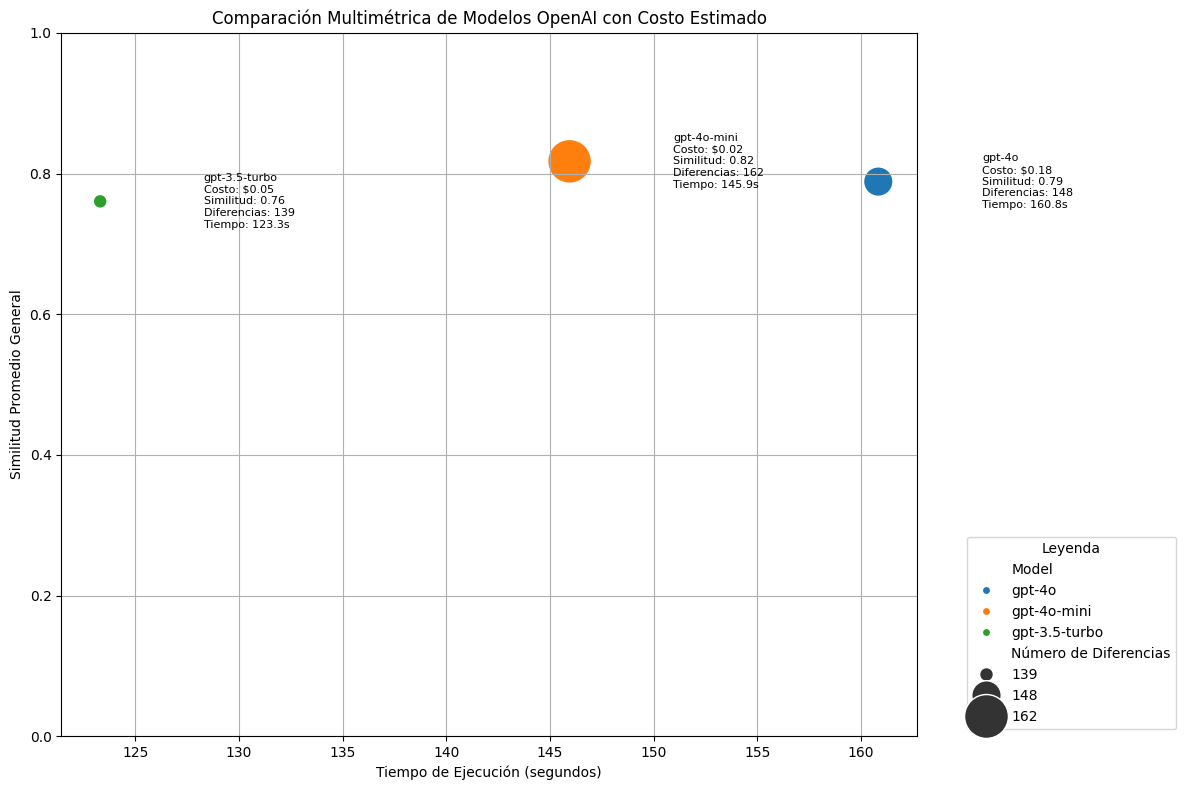

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import re

model_comparison_data = {
    'Model': ['gpt-4o', 'gpt-4o-mini', 'gpt-3.5-turbo'],
    'Overall Mean Similarity': [0.7885, 0.8173, 0.7604],
    'Number of Differences': [148, 162, 139],
    'Execution Time (seconds)': [160.83, 145.94, 123.30],
    'Input Cost (per 1M tokens)': [2.50, 0.15, 8.00],
    'Output Cost (per 1M tokens)': [10.00, 0.60, 6.00],
    'Actual Estimated Cost ($)': [0.18, 0.02, 0.05]
}

df_model_comparison = pd.DataFrame(model_comparison_data)

display(df_model_comparison)

# Crea un mapa de dispersion para comparar modelos basados en multiples metricas.
plt.figure(figsize=(12, 8))

ax = sns.scatterplot(data=df_model_comparison,
                x='Execution Time (seconds)',
                y='Overall Mean Similarity',
                size='Number of Differences',
                hue='Model',
                sizes=(100, 1000),
                legend='full')

for i in range(df_model_comparison.shape[0]):
    model_name = df_model_comparison['Model'][i]
    actual_cost = df_model_comparison['Actual Estimated Cost ($)'][i]
    similarity = df_model_comparison['Overall Mean Similarity'][i]
    differences = df_model_comparison['Number of Differences'][i]
    exec_time = df_model_comparison['Execution Time (seconds)'][i]

    label_text = f"{model_name}\nCosto: ${actual_cost:.2f}\nSimilitud: {similarity:.2f}\nDiferencias: {differences}\nTiempo: {exec_time:.1f}s"

    plt.text(x=df_model_comparison['Execution Time (seconds)'][i] + 5,
             y=df_model_comparison['Overall Mean Similarity'][i],
             s=label_text,
             fontdict=dict(color='black',size=8),
             ha='left',
             va='center')

plt.title('Comparación Multimétrica de Modelos OpenAI con Costo Estimado')
plt.xlabel('Tiempo de Ejecución (segundos)')
plt.ylabel('Similitud Promedio General')
plt.ylim(0, 1)
plt.grid(True)

handles, labels = ax.get_legend_handles_labels()

size_legend_title_index = -1
for i, label in enumerate(labels):
    if 'Number of Differences' in label:
        size_legend_title_index = i
        break

if size_legend_title_index != -1:
    labels[size_legend_title_index] = 'Número de Diferencias'

plt.legend(handles, labels, title='Leyenda', bbox_to_anchor=(1.05, 0), loc='lower left')


plt.tight_layout()
plt.show()

* gpt-4o:
Este modelo tiene el tiempo de ejecución más alto y un costo estimado de $0.18, que es el más alto de los tres. Su similitud promedio general es moderada (0.7885), y tiene un número intermedio de diferencias (148). En términos de costo-beneficio, parece ser menos eficiente que los otros modelos para esta tarea específica, ofreciendo un rendimiento de similitud similar o ligeramente inferior a un costo y tiempo considerablemente mayores. * **gpt-4o-mini:** Este modelo tiene un tiempo de ejecución intermedio y el costo estimado más bajo, solo $$0.18, que es el más alto de los tres. Su similitud promedio general es moderada (0.7885), y tiene un número intermedio de diferencias (148). En términos de costo-beneficio, parece ser menos eficiente que los otros modelos para esta tarea específica, ofreciendo un rendimiento de similitud similar o ligeramente inferior a un costo y tiempo considerablemente mayores.

* gpt-4o-mini:
Este modelo tiene un tiempo de ejecución intermedio y el costo estimado más bajo, solo $0.02. Logra la similitud promedio general más alta (0.8173). Aunque muestra un número ligeramente mayor de diferencias (162), su alta similitud promedio y su muy bajo costo lo posicionan como la opción más eficiente en términos de costo-beneficio para esta tarea. Ofrece el mejor rendimiento de similitud por una fracción del costo de los otros modelos.

* gpt-3.5-turbo:
Este modelo es el más rápido (menor tiempo de ejecución) y tiene un costo estimado bajo de $0.05, más alto que gpt-4o-mini pero significativamente más bajo que gpt-4o. Sin embargo, su similitud promedio general es la más baja (0.7604), aunque tiene el menor número de diferencias (139) lo cual es una métrica a considerar. gpt-3.5-turbo podría ser adecuado para escenarios donde la velocidad y el costo son las prioridades principales y una precisión ligeramente menor es aceptable, o para tareas de pre-filtrado.

Basado en los datos presentados y el costo estimado, gpt-4o-mini parece ser la opción más destacada en términos de relación costo-beneficio para esta tarea de comparación, ofreciendo la mejor similitud a un costo muy bajo. gpt-4o es el menos favorable en términos de costo-beneficio, mientras que gpt-3.5-turbo representa un punto intermedio útil para tareas más rápidas y de menor costo donde la máxima precisión no es crítica.

# Conclusión

El presente avance consolida la **fase experimental de comparación semántica y numérica** entre pre-notas y soportes dentro del proyecto **REINSURE.AI**.


Se probaron distintas variantes de modelos de OpenAI — **GPT-4o-mini**, **GPT-4o** y **GPT-3.5-Turbo** — con el objetivo de identificar el equilibrio óptimo entre **precisión, costo y tiempo de procesamiento**.  

Los resultados indican que:
- **GPT-4o-mini** ofrece un desempeño altamente competitivo en tareas de comparación textual, con tiempos de ejecución significativamente menores y costos hasta 10 veces más bajos por registro.  
- **GPT-4o** mejora la coherencia semántica en cláusulas extensas, pero incrementa considerablemente el costo y el tiempo de procesamiento.  
- **GPT-3.5-Turbo** muestra un rendimiento intermedio: buena velocidad, pero menor precisión en la interpretación de lenguaje legal complejo.  

En conjunto, **GPT-4o-mini** se perfila como la mejor opción base para los módulos de similitud y clasificación, mientras que **GPT-4o** podría reservarse para verificaciones finales de alta criticidad.

### Resultados de similitud promedio  
El análisis cuantitativo evidencia **variaciones claras entre dimensiones semánticas y numéricas**:
- Los campos **textuales y normativos** (`exclusiones`, `reinsurer`, `anexos_clausulas`) mantienen una similitud superior a **0.95**, reflejando alta consistencia documental.  
- Las variables **económicas y operativas** (`prima_neta`, `moneda`, `base_cobertura`) presentan valores medios entre **0.32 y 0.60**, mostrando discrepancias relevantes que deben ser auditadas.  

Estos hallazgos respaldan la necesidad de aplicar **normalización de unidades, monedas y bases de cobertura** antes de la evaluación semántica, para evitar falsos negativos en la comparación.

### Casos críticos detectados  
Se identificaron **folios con similitud nula (0.0)** en `prima_neta` y `moneda`, evidenciando **diferencias materiales en montos asegurados y denominaciones monetarias**.  
Estos registros fueron clasificados como *“negocios por revisar”*, representando puntos críticos para la validación contable y contractual.

REINSURE.AI avanza hacia convertirse en una **solución inteligente de validación contractual** que combina inteligencia artificial y conocimiento especializado en reaseguro.  
Los resultados obtenidos en este avance demuestran la **viabilidad técnica y económica** de automatizar comparaciones complejas entre documentos, abriendo el camino hacia un sistema escalable, auditable y adaptable a distintos portafolios de negocio.


